# Comparación de Espectrogramas: NoisyUAV Original vs. Artículo (Cropped)

Este notebook permite visualizar y comparar las muestras del dataset unificado y recortado del artículo (`NoisyUAV_articulo`) frente al dataset original (`NoisyUAV`), haciendo uso de las funciones oficiales del proyecto en `NoisyUAV`.

### ¿Por qué son fragmentos de 1.17 ms?
- **Dataset Original (NoisyUAV)**: Contiene archivos continuos de **74.9 ms (1,048,576 muestras)**. Dado que las transmisiones de los drones son esporádicas y en ráfagas (bursts) muy cortas (de 1 a 3 ms), gran parte del archivo es solo ruido o interferencia. Si etiquetamos todo el archivo como 'DJI', introducimos **label noise** (el modelo aprende que el silencio es DJI).
- **Dataset del Artículo (Cropped)**: Los autores recortaron la señal en fragmentos no solapados de **1.17 ms (16,384 muestras)** y calcularon el `duty_cycle`. Filtraron las muestras para asegurar que las clases de drones contengan transmisiones activas (con un `duty_cycle` medio de 42% a 77%, y nunca 0.0), eliminando el *label noise*. Las zonas sin transmisión se etiquetaron directamente como Clase 4 (Noise).

### Canales del Espectrograma (`x_spec`):
- **Canal 0**: Parte **Real** de la STFT compleja.
- **Canal 1**: Parte **Imaginaria** de la STFT compleja.
- Ambos canales están normalizados y tienen un tamaño de `128x128` (FFT de 128 puntos sin solapamiento sobre las 16,384 muestras). Mantener la parte real e imaginaria por separado conserva la fase del espectro, lo cual es crítico en RF Fingerprinting.

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# Añadir la raíz del repositorio para importar las funciones de visualización oficiales
sys.path.insert(0, r"c:\repos\DroneDetectionRF")

from NoisyUAV.funciones.visualizacion.visualizacion import panel_completo
from NoisyUAV.funciones.dataset.cargador import obtener_una_muestra as obtener_muestra_original

# Ruta al dataset recortado
dataset_path = r"C:\TFM_data\NoisyUAV_articulo\dataset.pt"

print("⏳ Cargando dataset.pt en memoria (puede tardar unos segundos)... ")
data = torch.load(dataset_path, map_location="cpu")

x_iq = data["x_iq"]         # [98705, 2, 16384]
x_spec = data["x_spec"]     # [98705, 2, 128, 128]
y = data["y"]               # [98705]
snr = data["snr"]           # [98705]
duty_cycle = data.get("duty_cycle") # [98705]

classes_map = {
    0: "DJI",
    1: "FutabaT14",
    2: "FutabaT7",
    3: "Graupner",
    4: "Noise (Ruido)",
    5: "Taranis",
    6: "Turnigy"
}

print(f"\n✅ Dataset cargado con éxito!")
print(f"   Dimensiones x_iq: {list(x_iq.shape)} (98,705 muestras, 2 canales I/Q, 16,384 puntos)")
print(f"   Dimensiones x_spec: {list(x_spec.shape)} (128x128, 2 canales)")

⏳ Cargando dataset.pt en memoria (puede tardar unos segundos)... 


C:\Users\Manuel\AppData\Local\Temp\ipykernel_22864\3816024633.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(dataset_path, map_location="cpu")



✅ Dataset cargado con éxito!
   Dimensiones x_iq: [98705, 2, 16384] (98,705 muestras, 2 canales I/Q, 16,384 puntos)
   Dimensiones x_spec: [98705, 2, 128, 128] (128x128, 2 canales)


In [12]:
# ===== PARÁMETROS DE SELECCIÓN DE MUESTRA =====
CLASE_DESEADA = 6      # 0=DJI, 1=FutabaT14, 2=FutabaT7, 3=Graupner, 4=Ruido, 5=Taranis, 6=Turnigy
SNR_DESEADA   = -10     # Relación señal-ruido en dB (-20 a 30)
# =============================================

# 1. Obtener muestra del original NoisyUAV (74.9 ms)
try:
    iq_orig, sample_id_orig, _, snr_real_orig = obtener_muestra_original(target=CLASE_DESEADA, snr=SNR_DESEADA, index=0)
    print(f"✅ Muestra original encontrada: ID #{sample_id_orig} | SNR real: {snr_real_orig} dB")
except Exception as e:
    print(f"⚠️ No se encontró muestra original en la ruta local. Error: {e}")
    iq_orig = None

# 2. Obtener muestra del cropped dataset (1.17 ms)
indices = torch.where((y == CLASE_DESEADA) & (snr == SNR_DESEADA))[0].numpy()
if len(indices) == 0:
    print(f"⚠️ No hay muestras para Clase={classes_map[CLASE_DESEADA]} y SNR={SNR_DESEADA} dB. Buscando SNR alternativa...")
    indices = torch.where(y == CLASE_DESEADA)[0].numpy()
    if len(indices) == 0:
        raise ValueError("No se encontraron muestras para esa clase.")

idx_crop = np.random.choice(indices)
iq_crop = x_iq[idx_crop]
spec_crop = x_spec[idx_crop]
dc_val = duty_cycle[idx_crop].item() if duty_cycle is not None else 0.0
print(f"✅ Muestra cropped seleccionada: Índice #{idx_crop} | SNR: {snr[idx_crop].item()} dB | Duty Cycle: {dc_val:.4f}")

✅ Muestra original encontrada: ID #8116 | SNR real: -10 dB
✅ Muestra cropped seleccionada: Índice #38982 | SNR: -10 dB | Duty Cycle: 0.6318


## 1. Visualización de la Muestra Original (74.9 ms)
Aquí observamos cómo la señal tiene mucha zona de "silencio" (solo ruido de fondo) e interferencias WiFi, lo que genera **label noise**.

c:\repos\DroneDetectionRF\NoisyUAV\funciones\visualizacion\visualizacion.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


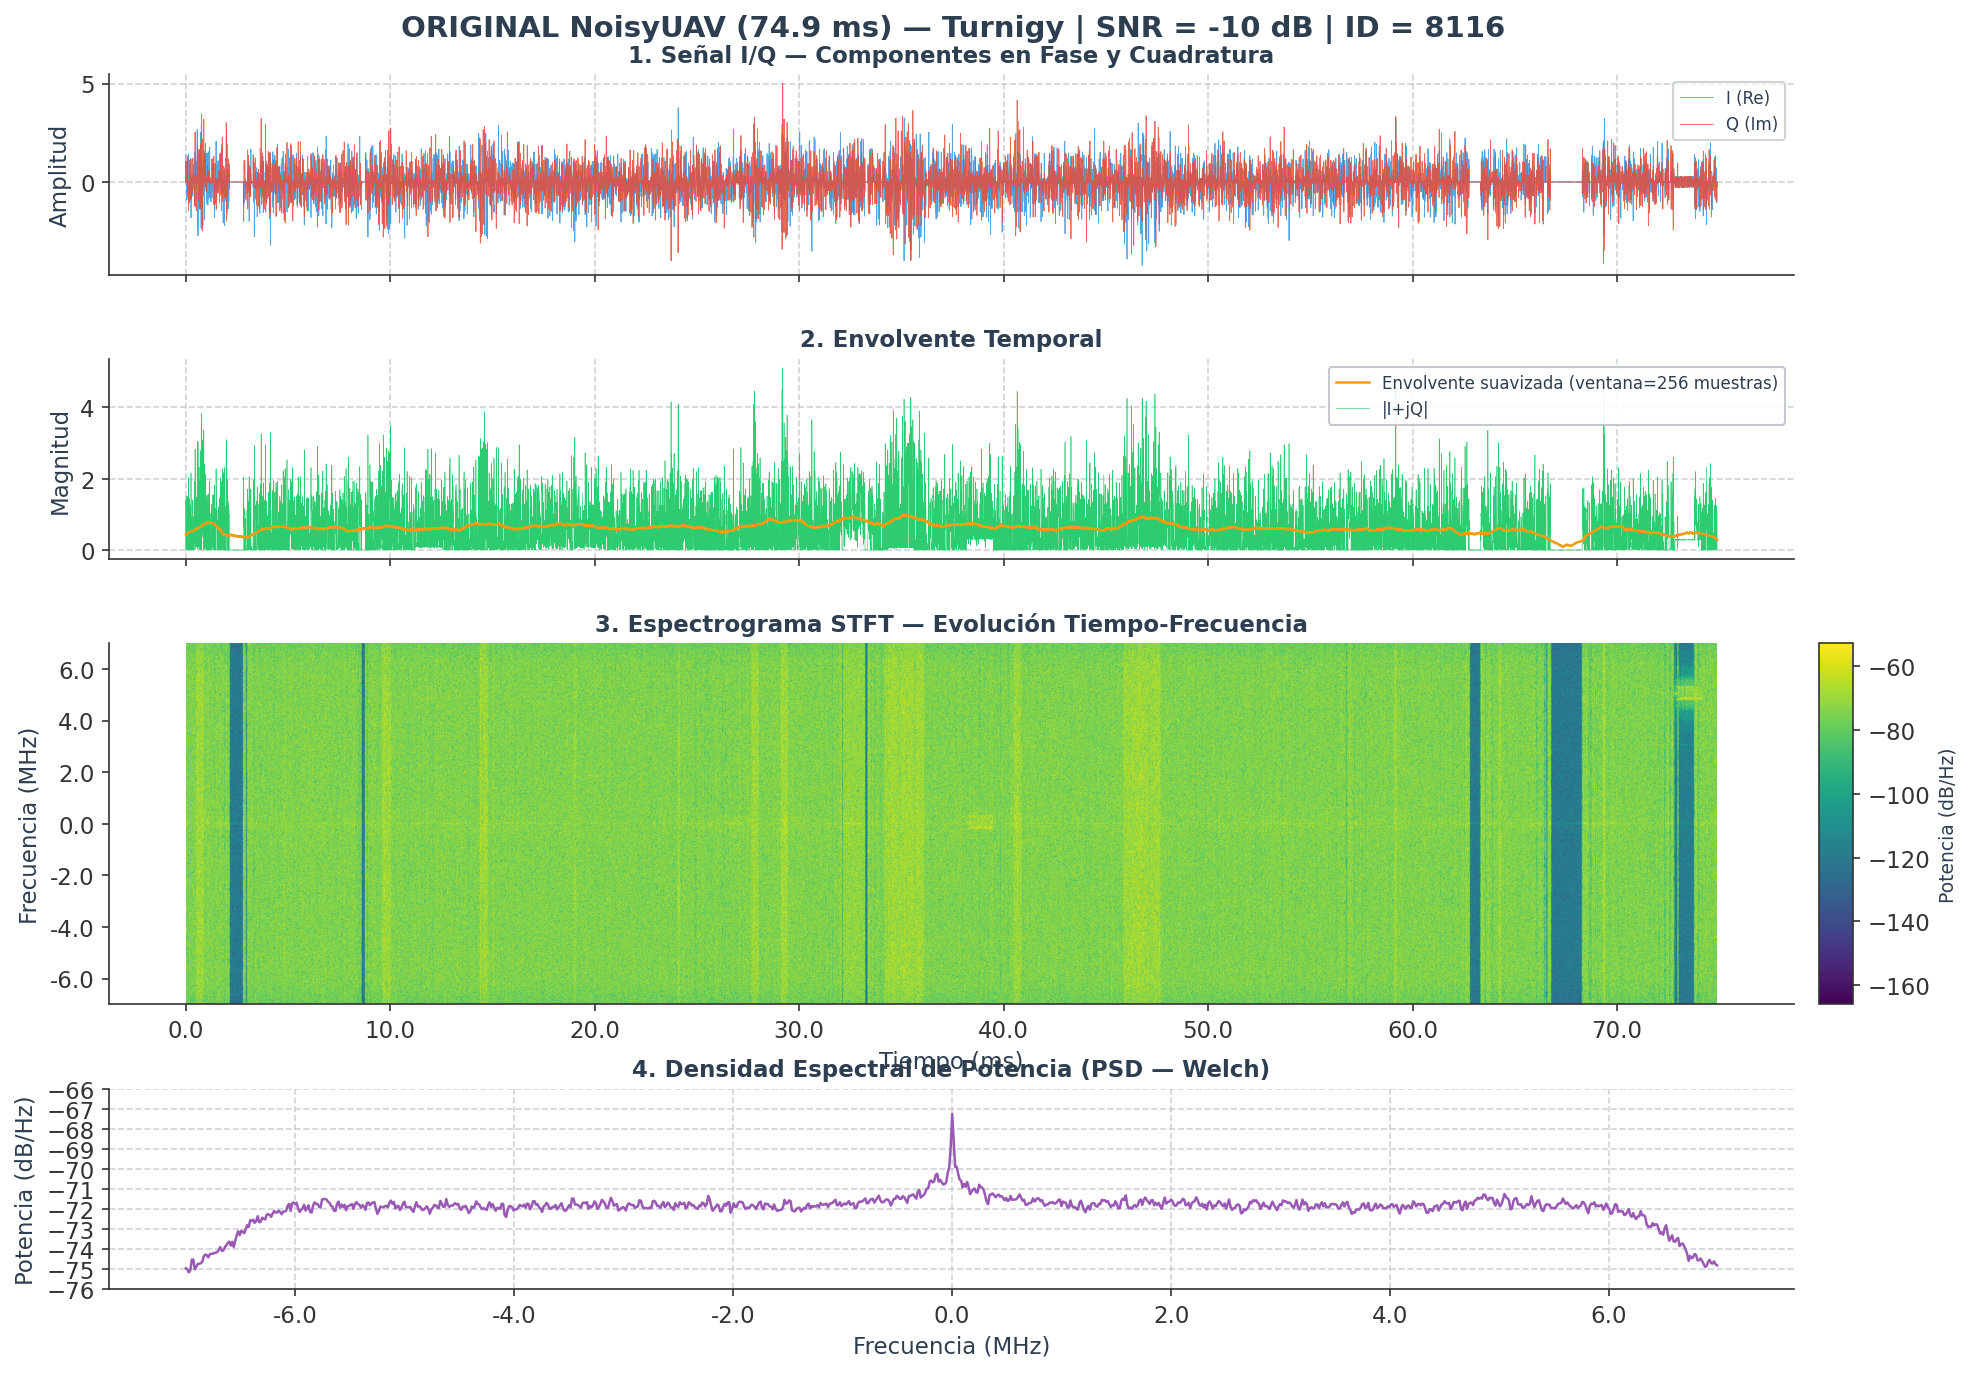

In [13]:
if iq_orig is not None:
    fig_orig = panel_completo(
        iq_tensor=iq_orig,
        target=CLASE_DESEADA,
        snr=snr_real_orig,
        sample_id=sample_id_orig,
        nfft=1024,
        figsize=(15, 10)
    )
    fig_orig.suptitle(f"ORIGINAL NoisyUAV (74.9 ms) — {classes_map[CLASE_DESEADA]} | SNR = {snr_real_orig} dB | ID = {sample_id_orig}", fontsize=14, fontweight="bold", y=0.96)
    plt.show()
else:
    print("Muestra original no disponible para visualización.")

## 2. Visualización de la Muestra Recortada (1.17 ms)
Ahora usamos el mismo visualizador oficial del proyecto, pero pasándole la señal recortada de 16,384 puntos. Se puede apreciar que la señal se enfoca directamente en la ráfaga de transmisión del dron.

c:\repos\DroneDetectionRF\NoisyUAV\funciones\visualizacion\visualizacion.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


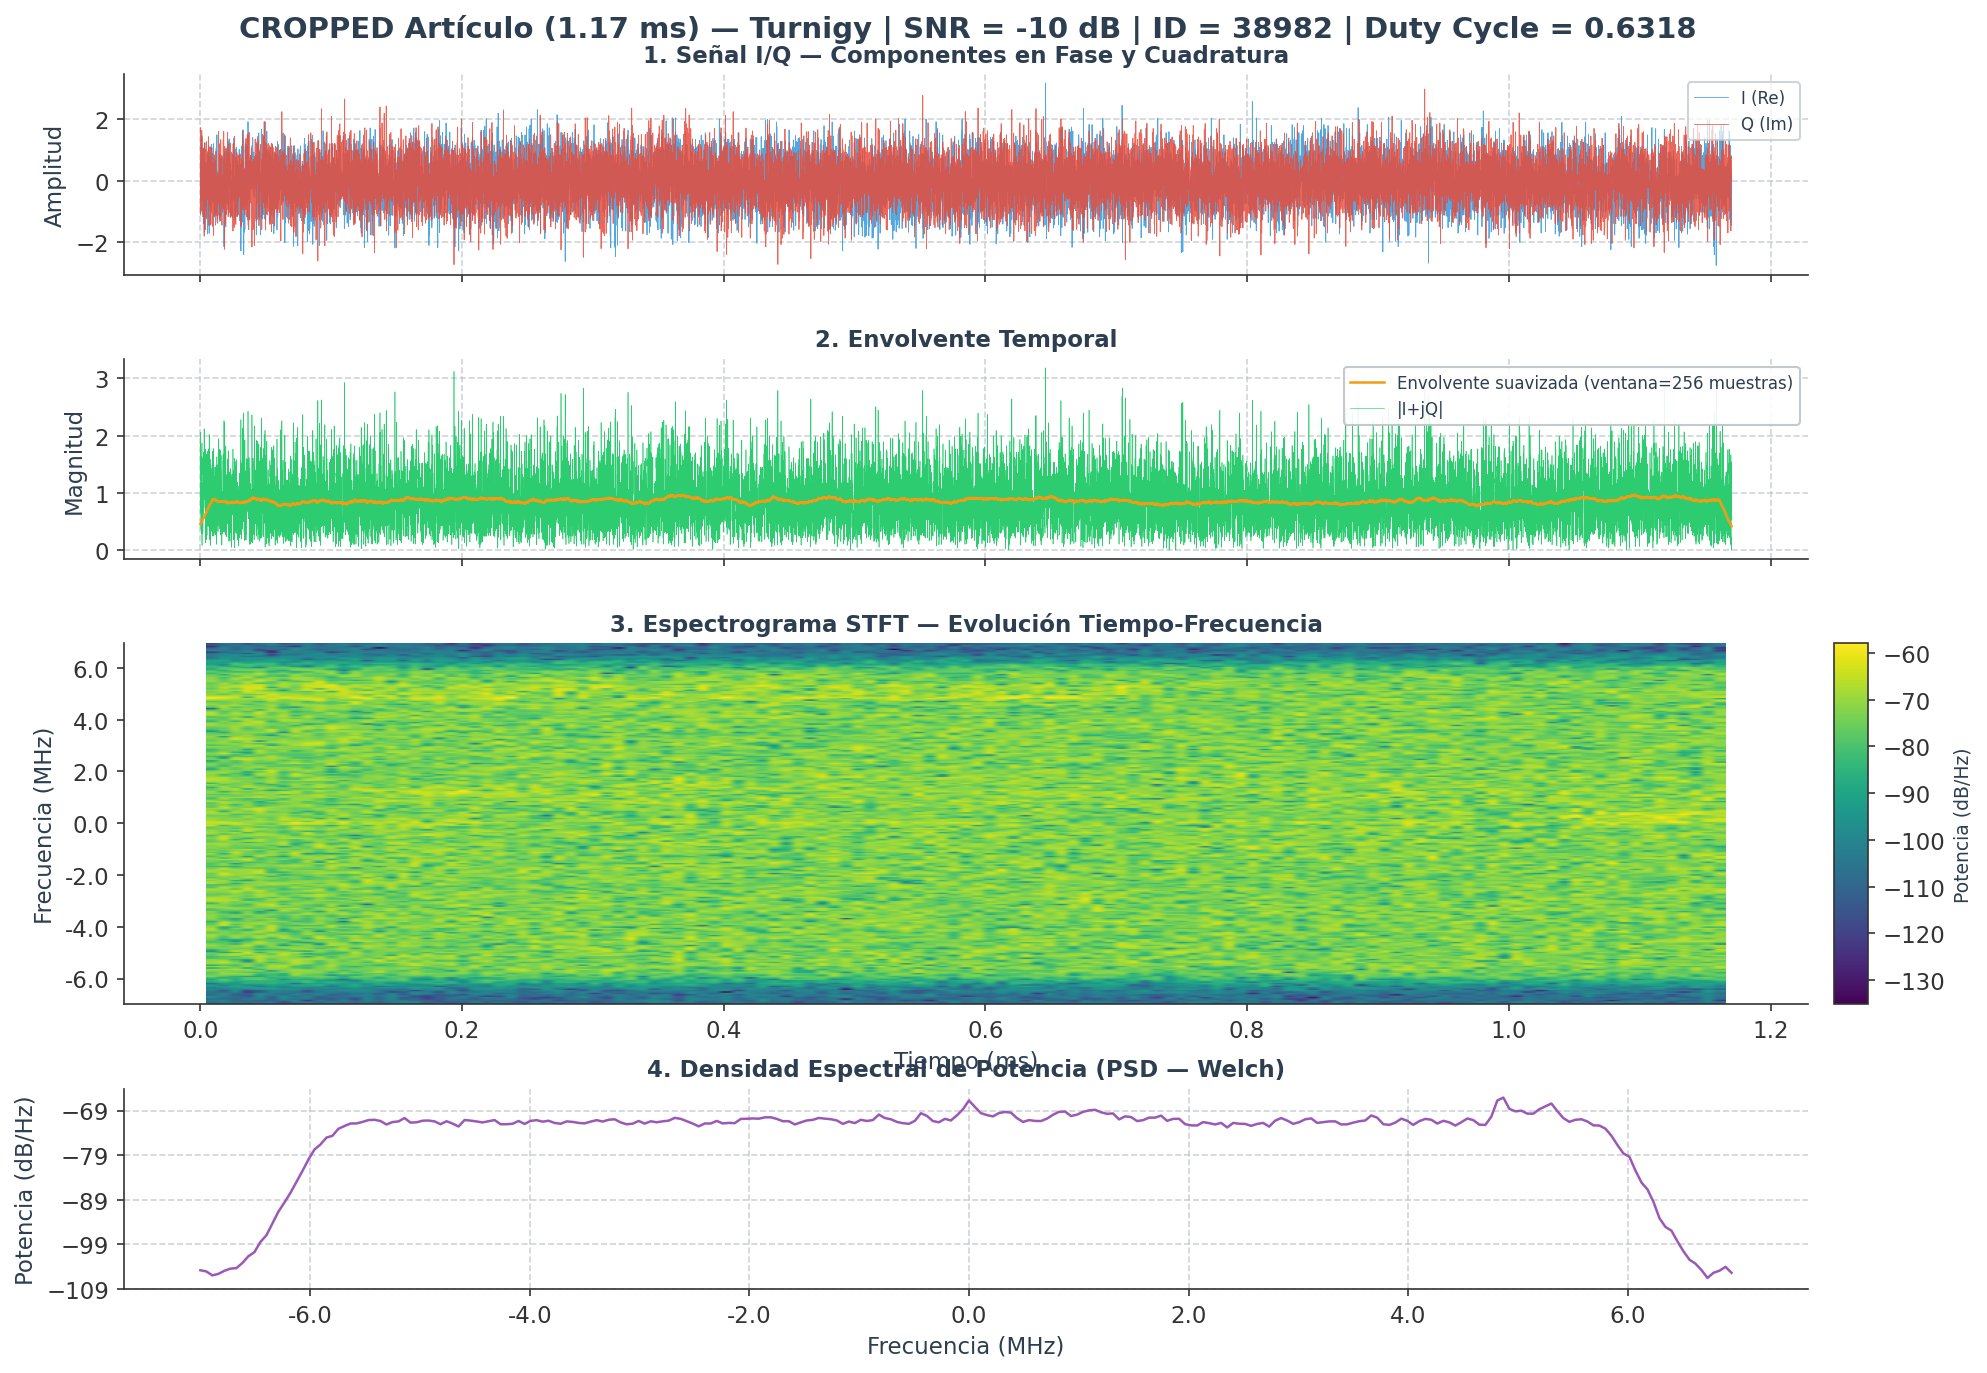

In [14]:
# Para señales de 1.17 ms (16,384 muestras), usar un NFFT de 256 o 512 da mejor resolución temporal
fig_crop = panel_completo(
    iq_tensor=iq_crop,
    target=CLASE_DESEADA,
    snr=snr[idx_crop].item(),
    sample_id=idx_crop,
    nfft=256,
    figsize=(15, 10)
)
fig_crop.suptitle(f"CROPPED Artículo (1.17 ms) — {classes_map[CLASE_DESEADA]} | SNR = {snr[idx_crop].item()} dB | ID = {idx_crop} | Duty Cycle = {dc_val:.4f}", fontsize=14, fontweight="bold", y=0.96)
plt.show()

## 3. Comparación: Espectrograma del Artículo vs. STFT en caliente
Aquí comparamos los dos canales de `x_spec` que vienen precalculados en el dataset frente a una STFT clásica calculada directamente a partir del I/Q crudo recortado (`x_iq`). 

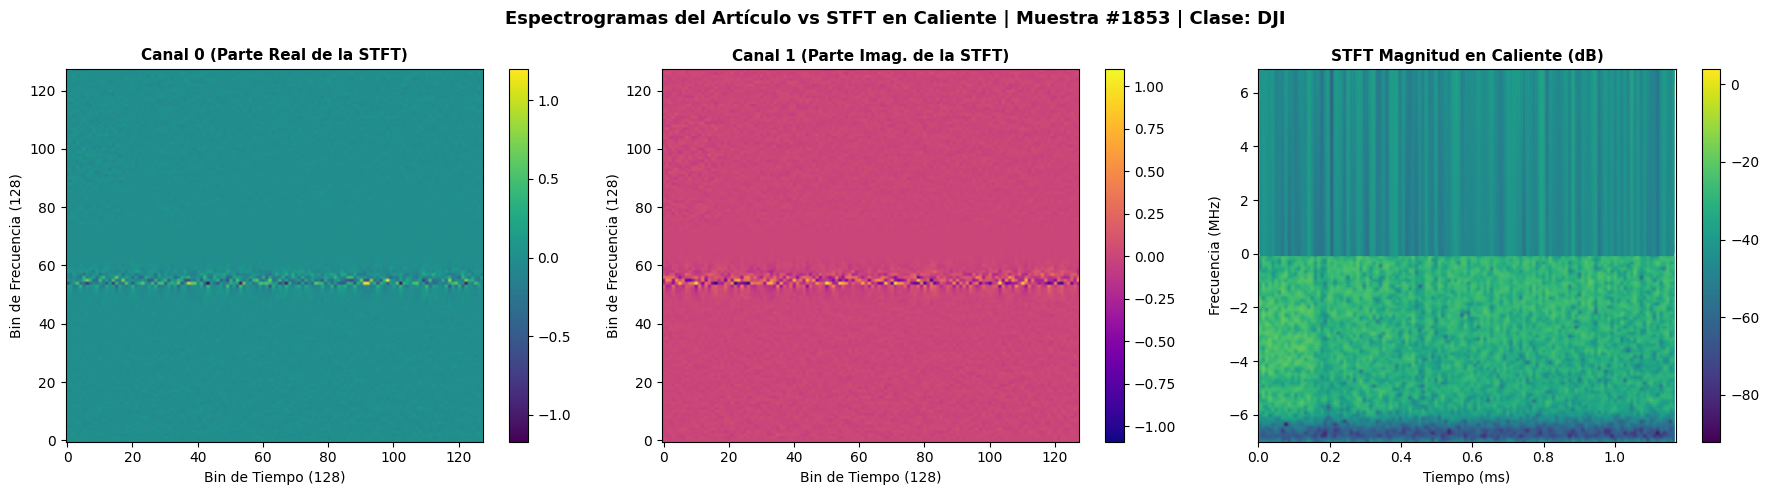

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Espectrogramas del Artículo vs STFT en Caliente | Muestra #{idx_crop} | Clase: {classes_map[CLASE_DESEADA]}", fontsize=13, fontweight='bold')

# 1. Espectrograma del Artículo (Canal 0 - Parte Real de STFT)
im0 = axes[0].imshow(spec_crop[0].numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title("Canal 0 (Parte Real de la STFT)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Bin de Tiempo (128)")
axes[0].set_ylabel("Bin de Frecuencia (128)")
fig.colorbar(im0, ax=axes[0])

# 2. Espectrograma del Artículo (Canal 1 - Parte Imaginaria de la STFT)
im1 = axes[1].imshow(spec_crop[1].numpy(), aspect='auto', origin='lower', cmap='plasma')
axes[1].set_title("Canal 1 (Parte Imag. de la STFT)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Bin de Tiempo (128)")
axes[1].set_ylabel("Bin de Frecuencia (128)")
fig.colorbar(im1, ax=axes[1])

# 3. Espectrograma dinámico calculado en caliente con scipy.signal.stft
FS = 14e6
complex_signal = iq_crop[0].numpy() + 1j * iq_crop[1].numpy()
f, t_stft, Zxx = signal.stft(complex_signal, fs=FS, nperseg=128, noverlap=0, return_onesided=False, boundary=None, padded=False)
Zxx_db = 20 * np.log10(np.abs(Zxx) + 1e-6)

im_stft = axes[2].pcolormesh(t_stft * 1000, f / 1e6, Zxx_db, shading='gouraud', cmap='viridis')
axes[2].set_title("STFT Magnitud en Caliente (dB)", fontsize=11, fontweight='bold')
axes[2].set_xlim([0, (16384/FS)*1000])
axes[2].set_xlabel("Tiempo (ms)")
axes[2].set_ylabel("Frecuencia (MHz)")
fig.colorbar(im_stft, ax=axes[2])

plt.tight_layout()
plt.show()